# Phenotype association analysis

This notebook summarizes phenotype-level scDRS-FM decomposition results across the Soskic, Nathan, Cano-Gamez, and microglia analyses.

Requested plotting updates included here:

- T-cell heatmaps plot every phenotype with at least one marginal association.
- Brain/microglia heatmaps plot all phenotypes.
- Brain phenotype labels remove `_gs` wherever it appears.
- Heatmap cells are square.
- Plot titles are omitted.
- Heatmap legends are included for marginal and conditional association stars.
- Every plotted phenotype–trait cell is saved as a manuscript-ready CSV row containing the exact heatmap value, marginal and conditional FDRs, significance flags, displayed marker state, source labels, and plot order.


In [1]:
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, List, Mapping, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from IPython.display import display

sns.set_style("white")

OUTPUT_DIR = Path("phenotype_analysis_outputs")
CSV_OUTPUT_DIR = OUTPUT_DIR / "csv"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CSV_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Analysis configuration

The T-cell phenotype heatmaps use the same trait ordering across Soskic, Cano-Gamez, and Nathan.  The first four traits are IBD-related, followed by autoimmune, respiratory/allergy, and hypothyroidism traits.

In [2]:
PHENOTYPE_TRAITS = [
    "PASS_CD_deLange2017",
    "PASS_UC_deLange2017",
    "PASS_IBD_deLange2017",
    "PASS_Celiac",
    "PASS_Rheumatoid_Arthritis",
    "UKB_460K.disease_AID_ALL",
    "UKB_460K.disease_ASTHMA_DIAGNOSED",
    "UKB_460K.disease_ALLERGY_ECZEMA_DIAGNOSED",
    "UKB_460K.disease_RESPIRATORY_ENT",
    "UKB_460K.disease_HYPOTHYROIDISM_SELF_REP",
]

TRAIT_NAME_MAP = {
    # Immune / autoimmune / inflammatory
    "PASS_CD_deLange2017": "Crohn’s Disease (CD)",
    "PASS_UC_deLange2017": "Ulcerative Colitis (UC)",
    "PASS_IBD_deLange2017": "Inflammatory Bowel Disease (IBD)",
    "PASS_Celiac": "Celiac Disease (CeD)",
    "PASS_Lupus": "Lupus",
    "PASS_Multiple_sclerosis": "Multiple Sclerosis (MS)",
    "PASS_Rheumatoid_Arthritis": "Rheumatoid Arthritis (RA)",
    "PASS_Type_1_Diabetes": "Type 1 Diabetes (T1D)",
    "PASS_Primary_biliary_cirrhosis": "Primary Biliary Cholangitis (PBC)",
    "UKB_460K.disease_AID_ALL": "Autoimmune Traits (AIT)",

    # Respiratory / allergy / endocrine
    "UKB_460K.disease_ASTHMA_DIAGNOSED": "Asthma",
    "UKB_460K.disease_ALLERGY_ECZEMA_DIAGNOSED": "Allergic Eczema (ECZ)",
    "UKB_460K.disease_RESPIRATORY_ENT": "Respiratory / ENT Disease (RESP-ENT)",
    "UKB_460K.disease_HYPOTHYROIDISM_SELF_REP": "Hypothyroidism (HYPO)",
}

# Row tick label colors for the 10 T-cell traits above.
TRAIT_COLOR_BLOCKS = {
    "red": 4,      # IBD-related traits
    "blue": 2,     # autoimmune traits
    "green": 3,    # respiratory/allergy traits
    "purple": 1,   # endocrine trait
}

@dataclass(frozen=True)
class PhenotypeDatasetConfig:
    """File, plotting, and source-data export configuration for one dataset."""
    name: str
    results_dir: Path
    traits: Sequence[str]
    trait_name_map: Mapping[str, str]
    fdr_threshold: float
    output_png: Path
    output_csv: Optional[Path] = None
    phenotype_name_map: Mapping[str, str] = None
    phenotype_mapping: Mapping[str, str] = None
    ytick_color_blocks: Optional[Mapping[str, int]] = None
    phenotype_filter: str = "marginal"  # one of: "marginal", "conditional", "all"

    def phenotype_files(self) -> List[Path]:
        """Return the expected decomposition files for all configured traits."""
        return [self.results_dir / f"{trait}.marg-marg.decomposition.tsv.gz" for trait in self.traits]

T_CELL_DATASETS = [
    PhenotypeDatasetConfig(
        name="soskic",
        results_dir=Path("ct_validations/soskic/scdrs+_results"),
        traits=PHENOTYPE_TRAITS,
        trait_name_map=TRAIT_NAME_MAP,
        fdr_threshold=0.05,
        output_png=OUTPUT_DIR / "cd4_pheno_marg_soskic.png",
        output_csv=CSV_OUTPUT_DIR / "soskic_phenotype_trait_plot_states.csv",
        phenotype_name_map={},
        phenotype_mapping={},
        ytick_color_blocks=TRAIT_COLOR_BLOCKS,
        phenotype_filter="marginal",
    ),
    PhenotypeDatasetConfig(
        name="canogamez",
        results_dir=Path("ct_validations/canogamez/scdrs+_results"),
        traits=PHENOTYPE_TRAITS,
        trait_name_map=TRAIT_NAME_MAP,
        fdr_threshold=0.05,
        output_png=OUTPUT_DIR / "cd4_pheno_marg_canogamez.png",
        output_csv=CSV_OUTPUT_DIR / "canogamez_phenotype_trait_plot_states.csv",
        phenotype_name_map={},
        phenotype_mapping={},
        ytick_color_blocks=TRAIT_COLOR_BLOCKS,
        phenotype_filter="marginal",
    ),
    PhenotypeDatasetConfig(
        name="nathan",
        results_dir=Path("ct_validations/nathan/scdrs+_results"),
        traits=PHENOTYPE_TRAITS,
        trait_name_map=TRAIT_NAME_MAP,
        fdr_threshold=0.05,
        output_png=OUTPUT_DIR / "cd4_pheno_marg_nathan.png",
        output_csv=CSV_OUTPUT_DIR / "nathan_phenotype_trait_plot_states.csv",
        phenotype_name_map={},
        phenotype_mapping={},
        ytick_color_blocks=TRAIT_COLOR_BLOCKS,
        phenotype_filter="marginal",
    ),
]

MICROGLIA_DATASET = PhenotypeDatasetConfig(
    name="microglia",
    results_dir=Path("sea_ad_final/healthy_results_filtered_martin"),
    traits=[
        "PASS_Parkinsons23andMe_Corces2020",
        "PASS_Alzheimers_Jansen2019",
    ],
    trait_name_map={
        "PASS_Parkinsons23andMe_Corces2020": "Parkinson’s Disease (PD)",
        "PASS_Alzheimers_Jansen2019": "Alzheimer’s Disease (AD)",
    },
    fdr_threshold=0.05,
    output_png=OUTPUT_DIR / "microglia_pheno_marg.png",
    output_csv=CSV_OUTPUT_DIR / "microglia_phenotype_trait_plot_states.csv",
    phenotype_name_map={},
    # Keep the mapping empty: `_gs` is removed automatically from all phenotype labels.
    phenotype_mapping={},
    ytick_color_blocks=None,
    phenotype_filter="all",
)


## Heatmap helper functions

The main plotting function reads one decomposition file per trait, maps trait and phenotype names to display labels, and overlays significance stars:

- hollow black star: marginal association only;
- blue star with black outline: conditional/multivariate association.

T-cell plots are filtered to phenotypes with at least one marginal association.  The brain/microglia plot is not phenotype-filtered.


In [3]:
def _check_files_exist(files: Sequence[Path]) -> None:
    """Fail early with a concise message if any required input files are missing."""
    missing = [str(path) for path in files if not Path(path).exists()]
    if missing:
        msg = "Missing required phenotype files:\n" + "\n".join(f"  - {p}" for p in missing)
        raise FileNotFoundError(msg)


def _read_decomposition_files(
    phenotype_files: Sequence[Path],
    *,
    trait_col: str = "trait",
) -> pd.DataFrame:
    """Read and concatenate phenotype-decomposition files with source provenance."""
    _check_files_exist(phenotype_files)

    frames = []
    for file in phenotype_files:
        file = Path(file)
        df = pd.read_csv(file, sep="\t")

        # Some files contain an unnamed index column. Drop it only when it is
        # clearly redundant; otherwise retain it for provenance/debugging.
        if "Unnamed: 0" in df.columns and trait_col in df.columns:
            df = df.drop(columns=["Unnamed: 0"])

        df = df.copy()
        df["_source_file"] = str(file)
        df["_source_file_name"] = file.name
        frames.append(df)

    if not frames:
        raise ValueError("No phenotype files were provided.")

    return pd.concat(frames, ignore_index=True)


def _clean_phenotype_label(
    phenotype: str,
    *,
    phenotype_name_map: Optional[Mapping[str, str]] = None,
    phenotype_mapping: Optional[Mapping[str, str]] = None,
) -> str:
    """Map phenotype names and remove `_gs` wherever it appears."""
    phenotype_name_map = phenotype_name_map or {}
    phenotype_mapping = phenotype_mapping or {}

    label = phenotype_name_map.get(phenotype, phenotype)
    label = phenotype_mapping.get(label, label)
    label = str(label).replace("_gs", "")
    return label


def _apply_tick_color_blocks(
    ticklabels,
    color_blocks: Optional[Mapping[str, int]],
    default_color: str = "black",
) -> None:
    """Color tick labels by consecutive blocks, preserving the input order."""
    for label in ticklabels:
        label.set_color(default_color)

    if color_blocks is None:
        return

    pos = 0
    for color, count in color_blocks.items():
        for i in range(pos, min(pos + int(count), len(ticklabels))):
            ticklabels[i].set_color(color)
        pos += int(count)


def _auto_square_heatmap_figsize(
    n_rows: int,
    n_cols: int,
    *,
    cell_size: float = 0.55,
    min_width: float = 4.0,
    min_height: float = 3.0,
    width_padding: float = 3.2,
    height_padding: float = 1.4,
) -> Tuple[float, float]:
    """Choose a figure size that leaves room for labels while keeping cells square."""
    width = max(min_width, n_cols * cell_size + width_padding)
    height = max(min_height, n_rows * cell_size + height_padding)
    return width, height


def _add_association_legend(
    ax: plt.Axes,
    *,
    fontsize: int = 11,
    marginal_star_size: int = 14,
    conditional_star_size: int = 14,
) -> None:
    """Add a legend explaining marginal and conditional association stars."""
    from matplotlib.lines import Line2D

    legend_handles = [
        Line2D(
            [], [],
            marker="*",
            linestyle="None",
            markerfacecolor="none",
            markeredgecolor="black",
            markeredgewidth=1.4,
            markersize=marginal_star_size,
            label="Marginal association",
        ),
        Line2D(
            [], [],
            marker="*",
            linestyle="None",
            markerfacecolor="lightskyblue",
            markeredgecolor="black",
            markeredgewidth=1.2,
            markersize=conditional_star_size,
            label="Conditional association",
        ),
    ]

    ax.legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        frameon=True,
        fontsize=fontsize,
        borderaxespad=0.0,
    )


def _join_unique_values(values: Iterable[Any]) -> str:
    """Join non-missing values in first-seen order for CSV provenance columns."""
    unique = []
    seen = set()
    for value in values:
        if pd.isna(value):
            continue
        text = str(value)
        if text not in seen:
            seen.add(text)
            unique.append(text)
    return " | ".join(unique)


def _matrix_to_long(matrix: pd.DataFrame, value_name: str) -> pd.DataFrame:
    """Convert a trait-by-phenotype matrix to a stable long-form table."""
    return (
        matrix.rename_axis(index="trait_display", columns="phenotype_display")
        .reset_index()
        .melt(
            id_vars="trait_display",
            var_name="phenotype_display",
            value_name=value_name,
        )
    )


def _build_phenotype_trait_state_table(
    data: pd.DataFrame,
    *,
    dataset_name: str,
    trait_col: str,
    phenotype_col: str,
    variance_col: str,
    marginal_fdr_col: str,
    conditional_fdr_col: Optional[str],
    has_conditional_fdr: bool,
    fdr_threshold: float,
    phenotype_filter: str,
    require_conditional_also_marginal: bool,
    included_phenotypes: Sequence[str],
    plot_trait_order: Sequence[str],
    plot_phenotype_order: Sequence[str],
) -> pd.DataFrame:
    """
    Build one manuscript-ready row for every candidate phenotype–trait pair.

    The aggregation exactly mirrors the heatmap: mean variance explained, minimum
    FDR, and logical-any significance. `included_in_plot` identifies the rows that
    were actually rendered after phenotype filtering.
    """
    all_trait_order = list(dict.fromkeys(data["trait_display"].tolist()))
    all_phenotype_order = list(dict.fromkeys(data["phenotype_display"].tolist()))

    variance_mat = data.pivot_table(
        index="trait_display",
        columns="phenotype_display",
        values=variance_col,
        aggfunc="mean",
    ).reindex(index=all_trait_order, columns=all_phenotype_order)

    marginal_fdr_mat = data.pivot_table(
        index="trait_display",
        columns="phenotype_display",
        values=marginal_fdr_col,
        aggfunc="min",
    ).reindex(index=all_trait_order, columns=all_phenotype_order)

    if has_conditional_fdr:
        conditional_fdr_mat = data.pivot_table(
            index="trait_display",
            columns="phenotype_display",
            values=conditional_fdr_col,
            aggfunc="min",
        ).reindex(index=all_trait_order, columns=all_phenotype_order)
    else:
        conditional_fdr_mat = pd.DataFrame(
            np.nan,
            index=all_trait_order,
            columns=all_phenotype_order,
        )

    marginal_mat = data.pivot_table(
        index="trait_display",
        columns="phenotype_display",
        values="is_marginal_sig",
        aggfunc="max",
    ).reindex(index=all_trait_order, columns=all_phenotype_order).fillna(False).astype(bool)

    conditional_mat = data.pivot_table(
        index="trait_display",
        columns="phenotype_display",
        values="is_conditional_sig",
        aggfunc="max",
    ).reindex(index=all_trait_order, columns=all_phenotype_order).fillna(False).astype(bool)

    row_count_data = data.assign(_source_row_count=1)
    row_count_mat = row_count_data.pivot_table(
        index="trait_display",
        columns="phenotype_display",
        values="_source_row_count",
        aggfunc="sum",
        fill_value=0,
    ).reindex(index=all_trait_order, columns=all_phenotype_order).fillna(0).astype(int)

    state = _matrix_to_long(variance_mat, "variance_explained_percent")
    for matrix, value_name in [
        (marginal_fdr_mat, "marginal_fdr"),
        (conditional_fdr_mat, "conditional_fdr"),
        (marginal_mat, "is_marginal_sig"),
        (conditional_mat, "is_conditional_sig"),
        (row_count_mat, "n_source_rows"),
    ]:
        state = state.merge(
            _matrix_to_long(matrix, value_name),
            on=["trait_display", "phenotype_display"],
            how="left",
            validate="one_to_one",
        )

    pair_meta = (
        data.groupby(["trait_display", "phenotype_display"], sort=False, dropna=False)
        .agg(
            {
                trait_col: _join_unique_values,
                phenotype_col: _join_unique_values,
                "_source_file_name": _join_unique_values,
                "_source_file": _join_unique_values,
            }
        )
        .reset_index()
        .rename(
            columns={
                trait_col: "trait_source_id",
                phenotype_col: "phenotype_source_id",
                "_source_file_name": "source_file_names",
                "_source_file": "source_files",
            }
        )
    )
    state = state.merge(
        pair_meta,
        on=["trait_display", "phenotype_display"],
        how="left",
        validate="one_to_one",
    )

    state["n_source_rows"] = state["n_source_rows"].fillna(0).astype(int)
    state["has_source_observation"] = state["n_source_rows"] > 0
    state["is_marginal_sig"] = state["is_marginal_sig"].fillna(False).astype(bool)
    state["is_conditional_sig"] = state["is_conditional_sig"].fillna(False).astype(bool)

    included_set = set(included_phenotypes)
    state["included_in_plot"] = state["phenotype_display"].isin(included_set)
    state["plot_status"] = np.where(
        state["included_in_plot"],
        "plotted",
        "excluded_by_phenotype_filter",
    )

    all_trait_order_map = {label: i + 1 for i, label in enumerate(all_trait_order)}
    all_phenotype_order_map = {label: i + 1 for i, label in enumerate(all_phenotype_order)}
    plot_trait_order_map = {label: i + 1 for i, label in enumerate(plot_trait_order)}
    plot_phenotype_order_map = {label: i + 1 for i, label in enumerate(plot_phenotype_order)}

    state["all_trait_order"] = state["trait_display"].map(all_trait_order_map).astype("Int64")
    state["all_phenotype_order"] = state["phenotype_display"].map(all_phenotype_order_map).astype("Int64")
    state["plot_row_order"] = state["trait_display"].map(plot_trait_order_map).astype("Int64")
    state["plot_column_order"] = state["phenotype_display"].map(plot_phenotype_order_map).astype("Int64")

    marginal = state["is_marginal_sig"].to_numpy(dtype=bool)
    conditional = state["is_conditional_sig"].to_numpy(dtype=bool)
    observed = state["has_source_observation"].to_numpy(dtype=bool)

    state["association_state"] = np.select(
        [
            ~observed,
            marginal & conditional,
            (~marginal) & conditional,
            marginal & (~conditional),
        ],
        [
            "missing_input",
            "marginal_and_conditional",
            "conditional_only",
            "marginal_only",
        ],
        default="not_significant",
    )

    state["marker_state"] = np.select(
        [conditional, marginal],
        ["filled_blue_conditional_star", "hollow_marginal_star"],
        default="none",
    )
    state["plotted_marker"] = np.where(
        state["included_in_plot"],
        state["marker_state"],
        "not_rendered",
    )
    state["rendered_heatmap_value_percent"] = state["variance_explained_percent"].where(
        state["included_in_plot"]
    )

    state["dataset"] = dataset_name
    state["fdr_threshold"] = float(fdr_threshold)
    state["phenotype_filter"] = phenotype_filter
    state["require_conditional_also_marginal"] = bool(require_conditional_also_marginal)
    state["conditional_significance_source"] = (
        conditional_fdr_col if has_conditional_fdr else f"{variance_col} > 0"
    )
    state["variance_aggregation"] = "mean"
    state["fdr_aggregation"] = "minimum"
    state["significance_aggregation"] = "any"

    preferred_columns = [
        "dataset",
        "trait_source_id",
        "trait_display",
        "phenotype_source_id",
        "phenotype_display",
        "included_in_plot",
        "plot_status",
        "plot_row_order",
        "plot_column_order",
        "all_trait_order",
        "all_phenotype_order",
        "variance_explained_percent",
        "rendered_heatmap_value_percent",
        "marginal_fdr",
        "conditional_fdr",
        "is_marginal_sig",
        "is_conditional_sig",
        "association_state",
        "marker_state",
        "plotted_marker",
        "has_source_observation",
        "n_source_rows",
        "fdr_threshold",
        "phenotype_filter",
        "require_conditional_also_marginal",
        "conditional_significance_source",
        "variance_aggregation",
        "fdr_aggregation",
        "significance_aggregation",
        "source_file_names",
        "source_files",
    ]
    remaining_columns = [column for column in state.columns if column not in preferred_columns]
    state = state[preferred_columns + remaining_columns]
    state = state.sort_values(
        ["all_trait_order", "all_phenotype_order"],
        kind="stable",
    ).reset_index(drop=True)
    return state


def _write_plot_state_csv(state_table: pd.DataFrame, savepath: Path) -> Path:
    """Write a stable, UTF-8 CSV for manuscript source-data deposition."""
    savepath = Path(savepath)
    savepath.parent.mkdir(parents=True, exist_ok=True)
    state_table.to_csv(
        savepath,
        index=False,
        encoding="utf-8",
        na_rep="",
        float_format="%.10g",
    )
    print(f"Saved plot-state CSV ({len(state_table):,} rows): {savepath}")
    return savepath


def plot_phenotype_association_heatmap(
    phenotype_files: Sequence[Path],
    trait_name_map: Optional[Mapping[str, str]] = None,
    phenotype_name_map: Optional[Mapping[str, str]] = None,
    phenotype_mapping: Optional[Mapping[str, str]] = None,
    *,
    dataset_name: Optional[str] = None,
    trait_col: str = "trait",
    phenotype_col: str = "phenotype",
    variance_col: str = "multivariate_var_explained",
    marginal_fdr_col: str = "univariate_fdr",
    conditional_fdr_col: Optional[str] = "multivariate_fdr",
    fdr_threshold: float = 0.05,
    require_conditional_also_marginal: bool = False,
    phenotype_filter: str = "marginal",
    only_show_phenotypes_with_conditional: Optional[bool] = None,
    figsize: Optional[Tuple[float, float]] = None,
    cell_size: float = 0.55,
    dpi: int = 120,
    cmap: str = "Reds",
    vmin: float = 0.0,
    vmax: Optional[float] = None,
    cbar_label: str = "Variance explained (%)",
    title: Optional[str] = None,
    tick_fontsize: int = 10,
    colorbar_tick_fontsize: int = 18,
    colorbar_label_fontsize: int = 20,
    marginal_star_size: int = 400,
    conditional_star_size: int = 395,
    legend_fontsize: int = 11,
    show_legend: bool = True,
    x_rotation: float = 45,
    y_rotation: float = 0,
    ytick_color_blocks: Optional[Mapping[str, int]] = None,
    ytick_default_color: str = "black",
    savepath: Optional[Path] = None,
    csv_savepath: Optional[Path] = None,
) -> Tuple[Optional[plt.Figure], Optional[plt.Axes], Dict[str, Any]]:
    """
    Plot a phenotype-association heatmap and export its exact cell states.

    Parameters
    ----------
    phenotype_filter:
        - "marginal": keep phenotypes with at least one marginal association.
        - "conditional": keep phenotypes with at least one conditional association.
        - "all": plot all phenotypes.
    csv_savepath:
        Optional long-form CSV path. One row is written for every rendered
        phenotype–trait cell, with the heatmap value and marker/significance state.

    Returns
    -------
    fig, ax, plotted_data
        Matplotlib objects plus raw, matrix, candidate-state, and exact plotted-state
        tables. If no phenotype passes the requested filter, the CSV is still written
        with headers and the function returns `(None, None, plotted_data)` rather than
        stopping the rest of the notebook.
    """
    trait_name_map = trait_name_map or {}
    phenotype_name_map = phenotype_name_map or {}
    phenotype_mapping = phenotype_mapping or {}
    dataset_name = dataset_name or "phenotype_dataset"

    # Backward-compatible alias used by the first cleaned notebook.
    if only_show_phenotypes_with_conditional is not None:
        phenotype_filter = "conditional" if only_show_phenotypes_with_conditional else "all"

    valid_filters = {"marginal", "conditional", "all", "none"}  # "none" is an old alias for "all"
    if phenotype_filter not in valid_filters:
        raise ValueError(f"phenotype_filter must be one of {sorted(valid_filters)}")

    data = _read_decomposition_files(phenotype_files, trait_col=trait_col)

    required = [trait_col, phenotype_col, variance_col, marginal_fdr_col]
    missing = [col for col in required if col not in data.columns]
    if missing:
        raise ValueError(
            f"Missing required columns: {missing}. Available columns: {list(data.columns)}"
        )

    data = data.copy()
    data[variance_col] = pd.to_numeric(data[variance_col], errors="coerce")
    data[marginal_fdr_col] = pd.to_numeric(data[marginal_fdr_col], errors="coerce")

    has_conditional_fdr = conditional_fdr_col is not None and conditional_fdr_col in data.columns
    if has_conditional_fdr:
        data[conditional_fdr_col] = pd.to_numeric(data[conditional_fdr_col], errors="coerce")

    # Convert fractional R² values to percentages when the scale looks fractional.
    if data[variance_col].max(skipna=True) <= 1.5:
        data[variance_col] = data[variance_col] * 100.0

    data["trait_display"] = data[trait_col].map(lambda trait: trait_name_map.get(trait, trait))
    data["phenotype_display"] = data[phenotype_col].map(
        lambda phenotype: _clean_phenotype_label(
            phenotype,
            phenotype_name_map=phenotype_name_map,
            phenotype_mapping=phenotype_mapping,
        )
    )

    data["is_marginal_sig"] = data[marginal_fdr_col] <= fdr_threshold
    if has_conditional_fdr:
        data["is_conditional_sig"] = data[conditional_fdr_col] <= fdr_threshold
    else:
        data["is_conditional_sig"] = data[variance_col] > 0

    if require_conditional_also_marginal:
        data["is_conditional_sig"] = data["is_conditional_sig"] & data["is_marginal_sig"]

    all_data = data.copy()
    all_phenotypes = list(dict.fromkeys(all_data["phenotype_display"].tolist()))

    if phenotype_filter == "marginal":
        keep = all_data.groupby("phenotype_display", sort=False)["is_marginal_sig"].any()
        included_phenotypes = [phenotype for phenotype in all_phenotypes if bool(keep.get(phenotype, False))]
    elif phenotype_filter == "conditional":
        keep = all_data.groupby("phenotype_display", sort=False)["is_conditional_sig"].any()
        included_phenotypes = [phenotype for phenotype in all_phenotypes if bool(keep.get(phenotype, False))]
    else:
        included_phenotypes = all_phenotypes

    data = all_data.loc[all_data["phenotype_display"].isin(included_phenotypes)].copy()

    # Preserve first-seen ordering from the input files, exactly as used by the plot.
    plot_trait_order = list(dict.fromkeys(data["trait_display"].tolist()))
    plot_phenotype_order = list(dict.fromkeys(data["phenotype_display"].tolist()))

    candidate_state_table = _build_phenotype_trait_state_table(
        all_data,
        dataset_name=dataset_name,
        trait_col=trait_col,
        phenotype_col=phenotype_col,
        variance_col=variance_col,
        marginal_fdr_col=marginal_fdr_col,
        conditional_fdr_col=conditional_fdr_col,
        has_conditional_fdr=has_conditional_fdr,
        fdr_threshold=fdr_threshold,
        phenotype_filter=phenotype_filter,
        require_conditional_also_marginal=require_conditional_also_marginal,
        included_phenotypes=included_phenotypes,
        plot_trait_order=plot_trait_order,
        plot_phenotype_order=plot_phenotype_order,
    )
    plot_state_table = candidate_state_table.loc[
        candidate_state_table["included_in_plot"]
    ].copy().reset_index(drop=True)

    if csv_savepath is not None:
        _write_plot_state_csv(plot_state_table, csv_savepath)

    used_columns = {
        "variance_col": variance_col,
        "marginal_fdr_col": marginal_fdr_col,
        "conditional_fdr_col": conditional_fdr_col if has_conditional_fdr else f"{variance_col} > 0",
        "phenotype_filter": phenotype_filter,
    }

    if data.empty:
        print(
            f"Skipped {dataset_name} heatmap: no phenotypes passed the "
            f"{phenotype_filter!r} filter at FDR <= {fdr_threshold:g}."
        )
        plotted_data = {
            "raw": data,
            "all_raw": all_data,
            "plot_state_long": plot_state_table,
            "candidate_state_long": candidate_state_table,
            "variance_mat": pd.DataFrame(),
            "marginal_sig_mat": pd.DataFrame(),
            "conditional_sig_mat": pd.DataFrame(),
            "marginal_fdr_mat": pd.DataFrame(),
            "conditional_fdr_mat": pd.DataFrame(),
            "used_columns": used_columns,
            "plot_skipped_reason": "no_phenotypes_passed_filter",
        }
        return None, None, plotted_data

    variance_mat = data.pivot_table(
        index="trait_display",
        columns="phenotype_display",
        values=variance_col,
        aggfunc="mean",
    ).reindex(index=plot_trait_order, columns=plot_phenotype_order)

    marginal_fdr_mat = data.pivot_table(
        index="trait_display",
        columns="phenotype_display",
        values=marginal_fdr_col,
        aggfunc="min",
    ).reindex(index=plot_trait_order, columns=plot_phenotype_order)

    if has_conditional_fdr:
        conditional_fdr_mat = data.pivot_table(
            index="trait_display",
            columns="phenotype_display",
            values=conditional_fdr_col,
            aggfunc="min",
        ).reindex(index=plot_trait_order, columns=plot_phenotype_order)
    else:
        conditional_fdr_mat = pd.DataFrame(
            np.nan,
            index=plot_trait_order,
            columns=plot_phenotype_order,
        )

    marginal_mat = data.pivot_table(
        index="trait_display",
        columns="phenotype_display",
        values="is_marginal_sig",
        aggfunc="max",
    ).reindex(index=plot_trait_order, columns=plot_phenotype_order).fillna(False).astype(bool)

    conditional_mat = data.pivot_table(
        index="trait_display",
        columns="phenotype_display",
        values="is_conditional_sig",
        aggfunc="max",
    ).reindex(index=plot_trait_order, columns=plot_phenotype_order).fillna(False).astype(bool)

    n_rows, n_cols = variance_mat.shape
    if figsize is None:
        figsize = _auto_square_heatmap_figsize(n_rows, n_cols, cell_size=cell_size)

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    heatmap = sns.heatmap(
        variance_mat,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        linewidths=0.5,
        linecolor="white",
        square=True,
        cbar_kws={"label": cbar_label, "shrink": 0.7},
    )
    ax.set_aspect("equal", adjustable="box")

    # Plot titles intentionally omitted per requested style.
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=x_rotation, ha="right", fontsize=tick_fontsize)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=y_rotation, fontsize=tick_fontsize)

    _apply_tick_color_blocks(ax.get_yticklabels(), ytick_color_blocks, default_color=ytick_default_color)

    cbar = heatmap.collections[0].colorbar
    cbar.ax.tick_params(labelsize=colorbar_tick_fontsize)
    cbar.set_label(cbar_label, size=colorbar_label_fontsize)

    # Significance overlays. These rules are mirrored in the CSV `plotted_marker` column.
    for i in range(n_rows):
        for j in range(n_cols):
            is_marginal = bool(marginal_mat.iloc[i, j])
            is_conditional = bool(conditional_mat.iloc[i, j])

            if is_marginal and not is_conditional:
                ax.scatter(
                    j + 0.5,
                    i + 0.5,
                    marker="*",
                    s=marginal_star_size,
                    facecolors="none",
                    edgecolors="black",
                    linewidths=1.2,
                    zorder=5,
                )

            if is_conditional:
                ax.scatter(
                    j + 0.5,
                    i + 0.5,
                    marker="*",
                    s=conditional_star_size,
                    facecolors="lightskyblue",
                    edgecolors="black",
                    linewidths=1.0,
                    zorder=6,
                )

    if show_legend:
        _add_association_legend(
            ax,
            fontsize=legend_fontsize,
            marginal_star_size=max(10, int(np.sqrt(marginal_star_size) * 0.8)),
            conditional_star_size=max(10, int(np.sqrt(conditional_star_size) * 0.8)),
        )

    plotted_data = {
        "raw": data,
        "all_raw": all_data,
        "plot_state_long": plot_state_table,
        "candidate_state_long": candidate_state_table,
        "variance_mat": variance_mat,
        "marginal_sig_mat": marginal_mat,
        "conditional_sig_mat": conditional_mat,
        "marginal_fdr_mat": marginal_fdr_mat,
        "conditional_fdr_mat": conditional_fdr_mat,
        "used_columns": used_columns,
        "plot_skipped_reason": None,
    }

    fig.tight_layout()
    if savepath is not None:
        savepath = Path(savepath)
        savepath.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
        print(f"Saved: {savepath}")

    return fig, ax, plotted_data


## T-cell phenotype heatmaps

These heatmaps show all phenotypes with at least one marginal association in each T-cell dataset.  Titles are omitted, and the legend explains marginal and conditional association stars.


Plotting soskic phenotype heatmap
Saved plot-state CSV (100 rows): phenotype_analysis_outputs/csv/soskic_phenotype_trait_plot_states.csv
Saved: phenotype_analysis_outputs/cd4_pheno_marg_soskic.png


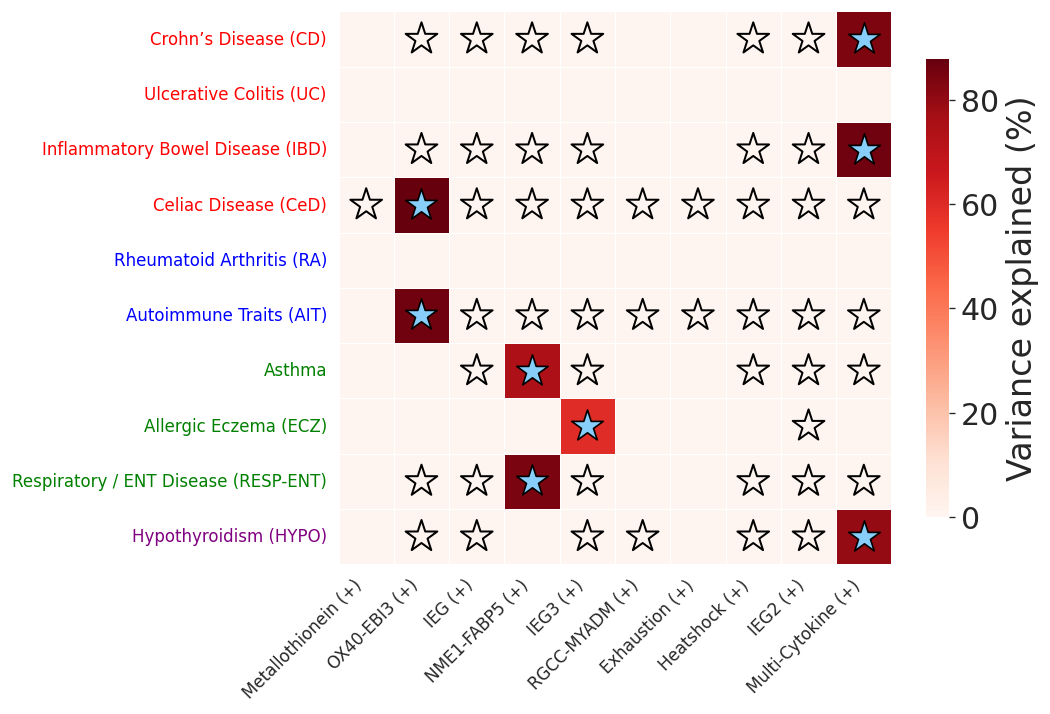

Plotting canogamez phenotype heatmap
Saved plot-state CSV (10 rows): phenotype_analysis_outputs/csv/canogamez_phenotype_trait_plot_states.csv
Saved: phenotype_analysis_outputs/cd4_pheno_marg_canogamez.png


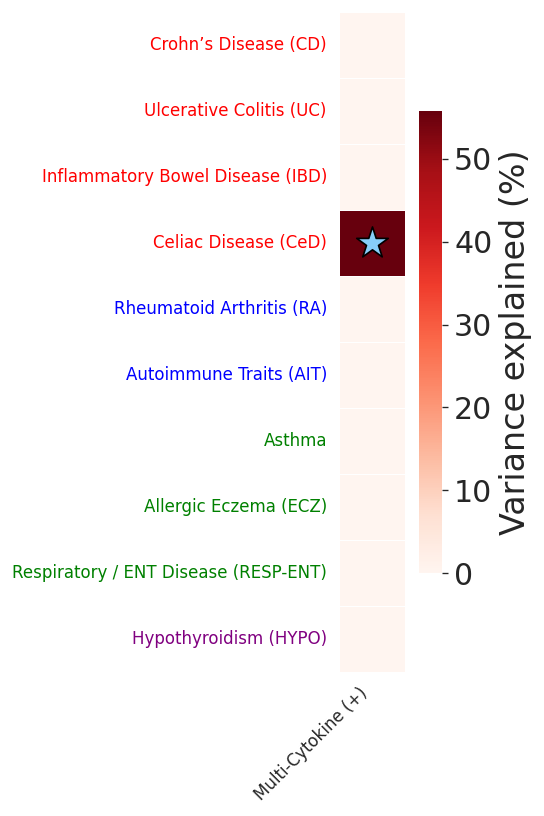

Plotting nathan phenotype heatmap
Saved plot-state CSV (0 rows): phenotype_analysis_outputs/csv/nathan_phenotype_trait_plot_states.csv
Skipped nathan heatmap: no phenotypes passed the 'marginal' filter at FDR <= 0.05.


In [4]:
phenotype_heatmap_outputs = {}

for config in T_CELL_DATASETS:
    print(f"Plotting {config.name} phenotype heatmap")

    fig, ax, plotted_data = plot_phenotype_association_heatmap(
        phenotype_files=config.phenotype_files(),
        dataset_name=config.name,
        trait_name_map=config.trait_name_map,
        phenotype_name_map=config.phenotype_name_map,
        phenotype_mapping=config.phenotype_mapping,
        require_conditional_also_marginal=False,
        phenotype_filter=config.phenotype_filter,
        fdr_threshold=config.fdr_threshold,
        title=None,
        ytick_color_blocks=config.ytick_color_blocks,
        tick_fontsize=10,
        colorbar_tick_fontsize=18,
        colorbar_label_fontsize=20,
        marginal_star_size=400,
        conditional_star_size=395,
        legend_fontsize=11,
        show_legend=False,
        cell_size=0.55,
        savepath=config.output_png,
        csv_savepath=config.output_csv,
    )

    phenotype_heatmap_outputs[config.name] = plotted_data
    if fig is not None:
        plt.show()


## Brain / microglia phenotype heatmap

This heatmap shows all available phenotypes. Phenotype labels are cleaned by removing `_gs` wherever it appears.


Saved plot-state CSV (20 rows): phenotype_analysis_outputs/csv/microglia_phenotype_trait_plot_states.csv
Saved: phenotype_analysis_outputs/microglia_pheno_marg.png


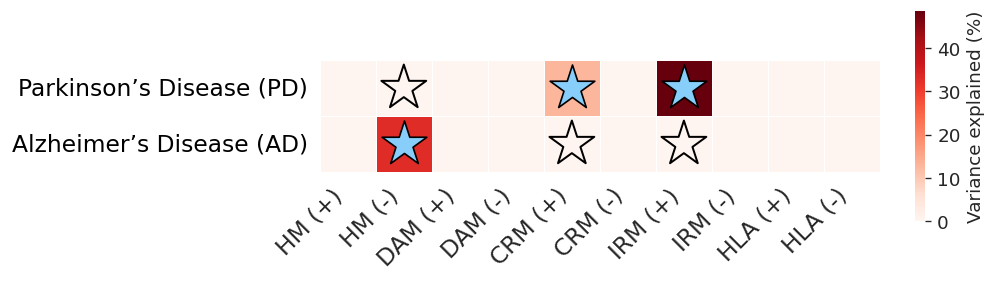

In [5]:
fig, ax, microglia_plotted_data = plot_phenotype_association_heatmap(
    phenotype_files=MICROGLIA_DATASET.phenotype_files(),
    dataset_name=MICROGLIA_DATASET.name,
    trait_name_map=MICROGLIA_DATASET.trait_name_map,
    phenotype_name_map=MICROGLIA_DATASET.phenotype_name_map,
    phenotype_mapping=MICROGLIA_DATASET.phenotype_mapping,
    require_conditional_also_marginal=False,
    phenotype_filter=MICROGLIA_DATASET.phenotype_filter,
    fdr_threshold=MICROGLIA_DATASET.fdr_threshold,
    title=None,
    tick_fontsize=14,
    colorbar_tick_fontsize=11,
    colorbar_label_fontsize=11,
    marginal_star_size=800,
    conditional_star_size=795,
    legend_fontsize=11,
    show_legend=False,
    cell_size=0.55,
    savepath=MICROGLIA_DATASET.output_png,
    csv_savepath=MICROGLIA_DATASET.output_csv,
)
phenotype_heatmap_outputs[MICROGLIA_DATASET.name] = microglia_plotted_data
if fig is not None:
    plt.show()


## Consolidated phenotype–trait plot-state CSVs

The per-dataset CSVs contain one row for every heatmap cell that was actually rendered. The combined tables below provide:

- every rendered phenotype–trait cell across all datasets;
- only rendered cells with a marginal and/or conditional association;
- every candidate cell before phenotype filtering, with `included_in_plot` recording whether it was rendered;
- a compact count summary and a CSV manifest.


In [6]:
plotted_tables = []
candidate_tables = []

for dataset_name, output in phenotype_heatmap_outputs.items():
    plotted = output.get("plot_state_long")
    candidates = output.get("candidate_state_long")

    if isinstance(plotted, pd.DataFrame):
        plotted_tables.append(plotted.copy())
    if isinstance(candidates, pd.DataFrame):
        candidate_tables.append(candidates.copy())

if not candidate_tables:
    raise ValueError("No phenotype–trait state tables were generated.")

all_candidate_states = pd.concat(candidate_tables, ignore_index=True, sort=False)
all_plotted_states = (
    pd.concat(plotted_tables, ignore_index=True, sort=False)
    if plotted_tables
    else all_candidate_states.iloc[0:0].copy()
)

significant_plotted_states = all_plotted_states.loc[
    all_plotted_states["association_state"].isin(
        ["marginal_only", "conditional_only", "marginal_and_conditional"]
    )
].copy()

combined_plotted_path = CSV_OUTPUT_DIR / "phenotype_trait_plotted_states_all_datasets.csv"
significant_plotted_path = CSV_OUTPUT_DIR / "phenotype_trait_significant_plotted_states.csv"
candidate_path = CSV_OUTPUT_DIR / "phenotype_trait_candidate_states_all_datasets.csv"
summary_path = CSV_OUTPUT_DIR / "phenotype_trait_plot_state_summary.csv"
manifest_path = CSV_OUTPUT_DIR / "phenotype_trait_csv_manifest.csv"

_write_plot_state_csv(all_plotted_states, combined_plotted_path)
_write_plot_state_csv(significant_plotted_states, significant_plotted_path)
_write_plot_state_csv(all_candidate_states, candidate_path)

plot_state_summary = (
    all_candidate_states.groupby(
        ["dataset", "included_in_plot", "association_state"],
        dropna=False,
        observed=True,
    )
    .size()
    .rename("n_phenotype_trait_cells")
    .reset_index()
    .sort_values(["dataset", "included_in_plot", "association_state"], kind="stable")
    .reset_index(drop=True)
)
plot_state_summary.to_csv(summary_path, index=False, encoding="utf-8")

manifest_rows = []
for config in [*T_CELL_DATASETS, MICROGLIA_DATASET]:
    manifest_rows.append(
        {
            "file": str(config.output_csv),
            "dataset": config.name,
            "scope": "rendered phenotype-trait cells",
            "description": "Exact numeric heatmap values, FDRs, significance states, rendered marker, and plot order.",
        }
    )
manifest_rows.extend(
    [
        {
            "file": str(combined_plotted_path),
            "dataset": "all",
            "scope": "all rendered phenotype-trait cells",
            "description": "Combined per-cell source data for every rendered phenotype heatmap.",
        },
        {
            "file": str(significant_plotted_path),
            "dataset": "all",
            "scope": "significant rendered cells",
            "description": "Rendered cells with a marginal and/or conditional association.",
        },
        {
            "file": str(candidate_path),
            "dataset": "all",
            "scope": "all candidate cells before phenotype filtering",
            "description": "Includes excluded phenotypes and records whether each cell was rendered.",
        },
        {
            "file": str(summary_path),
            "dataset": "all",
            "scope": "state counts",
            "description": "Counts of phenotype-trait cells by dataset, plot inclusion, and association state.",
        },
    ]
)
phenotype_trait_csv_manifest = pd.DataFrame(manifest_rows)
phenotype_trait_csv_manifest.to_csv(manifest_path, index=False, encoding="utf-8")

print(f"Saved summary CSV: {summary_path}")
print(f"Saved CSV manifest: {manifest_path}")
display(plot_state_summary)


Saved plot-state CSV (130 rows): phenotype_analysis_outputs/csv/phenotype_trait_plotted_states_all_datasets.csv
Saved plot-state CSV (62 rows): phenotype_analysis_outputs/csv/phenotype_trait_significant_plotted_states.csv
Saved plot-state CSV (740 rows): phenotype_analysis_outputs/csv/phenotype_trait_candidate_states_all_datasets.csv
Saved summary CSV: phenotype_analysis_outputs/csv/phenotype_trait_plot_state_summary.csv
Saved CSV manifest: phenotype_analysis_outputs/csv/phenotype_trait_csv_manifest.csv


,dataset,included_in_plot,association_state,n_phenotype_trait_cells
0,canogamez,False,conditional_only,3
1,canogamez,False,not_significant,227
2,canogamez,True,marginal_and_conditional,1
3,canogamez,True,not_significant,9
4,microglia,True,marginal_and_conditional,3
5,microglia,True,marginal_only,3
6,microglia,True,not_significant,14
7,nathan,False,conditional_only,4
8,nathan,False,not_significant,236
9,soskic,False,not_significant,140
